# Assignemt 1 Characterising an AMOC timeseries

**Author**: Hengxi Yang

**Date**: Sep 2026

## Data and Series

· **Dataset**: Denmark Strait Overflow, DSO, hourly

· **Series**: Overflow time-series through Denmark Strait

· **Timespa**n: 1996-05-01 to 2021-08-07

· **Record length**: 221,514


In [71]:
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [72]:
import sys
from pathlib import Path

root_dir = Path.cwd().resolve().parent
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))



In [73]:
import numpy as np
import scipy.signal as signal

from amocatlas import read
from amoc_analysis.analysis import report_dataset_info
from amoc_analysis.analysis import compute_transport_stats
from amoc_analysis.plotting import plot_transport_distribution
from amoc_analysis.analysis import calculate_welch_psd
from amoc_analysis.plotting import plot_welch_psd
from amoc_analysis.analysis import verify_with_parseval
from amoc_analysis.analysis import apply_tukey_lowpass_filter, calculate_welch_psd
from amoc_analysis.plotting import plot_filtered_comparison, plot_psd_comparison
from amoc_analysis.plotting import plot_filter_frequency_responses
from amoc_analysis.analysis import compute_confidence_interval
from amoc_analysis.plotting import plot_psd_with_confidence_interval

## Part A Characterise the Series

Load dataset

In [74]:

ds_dso = read.dso()

# 1-D array
series_dso = ds_dso['TRANS_DSO'].isel(DEPTH = 0)

# report info
report_dataset_info(series_dso, var_name = "DSO")

Loading 1 Denmark Strait Overflow dataset(s):
  0. DSO_transport_hourly_1996_2021.nc: Overflow time-series through Denmark Strait

********************
Record length is 221514 time steps
Timespan is from 1996-05-01 to 2021-08-07
Sampling Interval is Approximately 1 hours
18456 Missing values


Use linear interpolation to fill the NaN position

In [75]:
# linear interpolation
series_clean = series_dso.interpolate_na(dim = "TIME", method = "linear")

# drop the remaining NaNs at both ends
series_clean = series_clean.dropna(dim = "TIME")

# report again
report_dataset_info(series_clean, var_name = "TRANS_DSO")

********************
Record length is 220956 time steps
Timespan is from 1996-05-24 to 2021-08-07
Sampling Interval is Approximately 1 hours
0 Missing values


Interpret the mean, standard deviation and range.

Mean: -3.125 Sv
Standard Deviation: 1.457 Sv
Minimum: -9.661 Sv
Maximum: 3.084 Sv
Range: 12.745 Sv


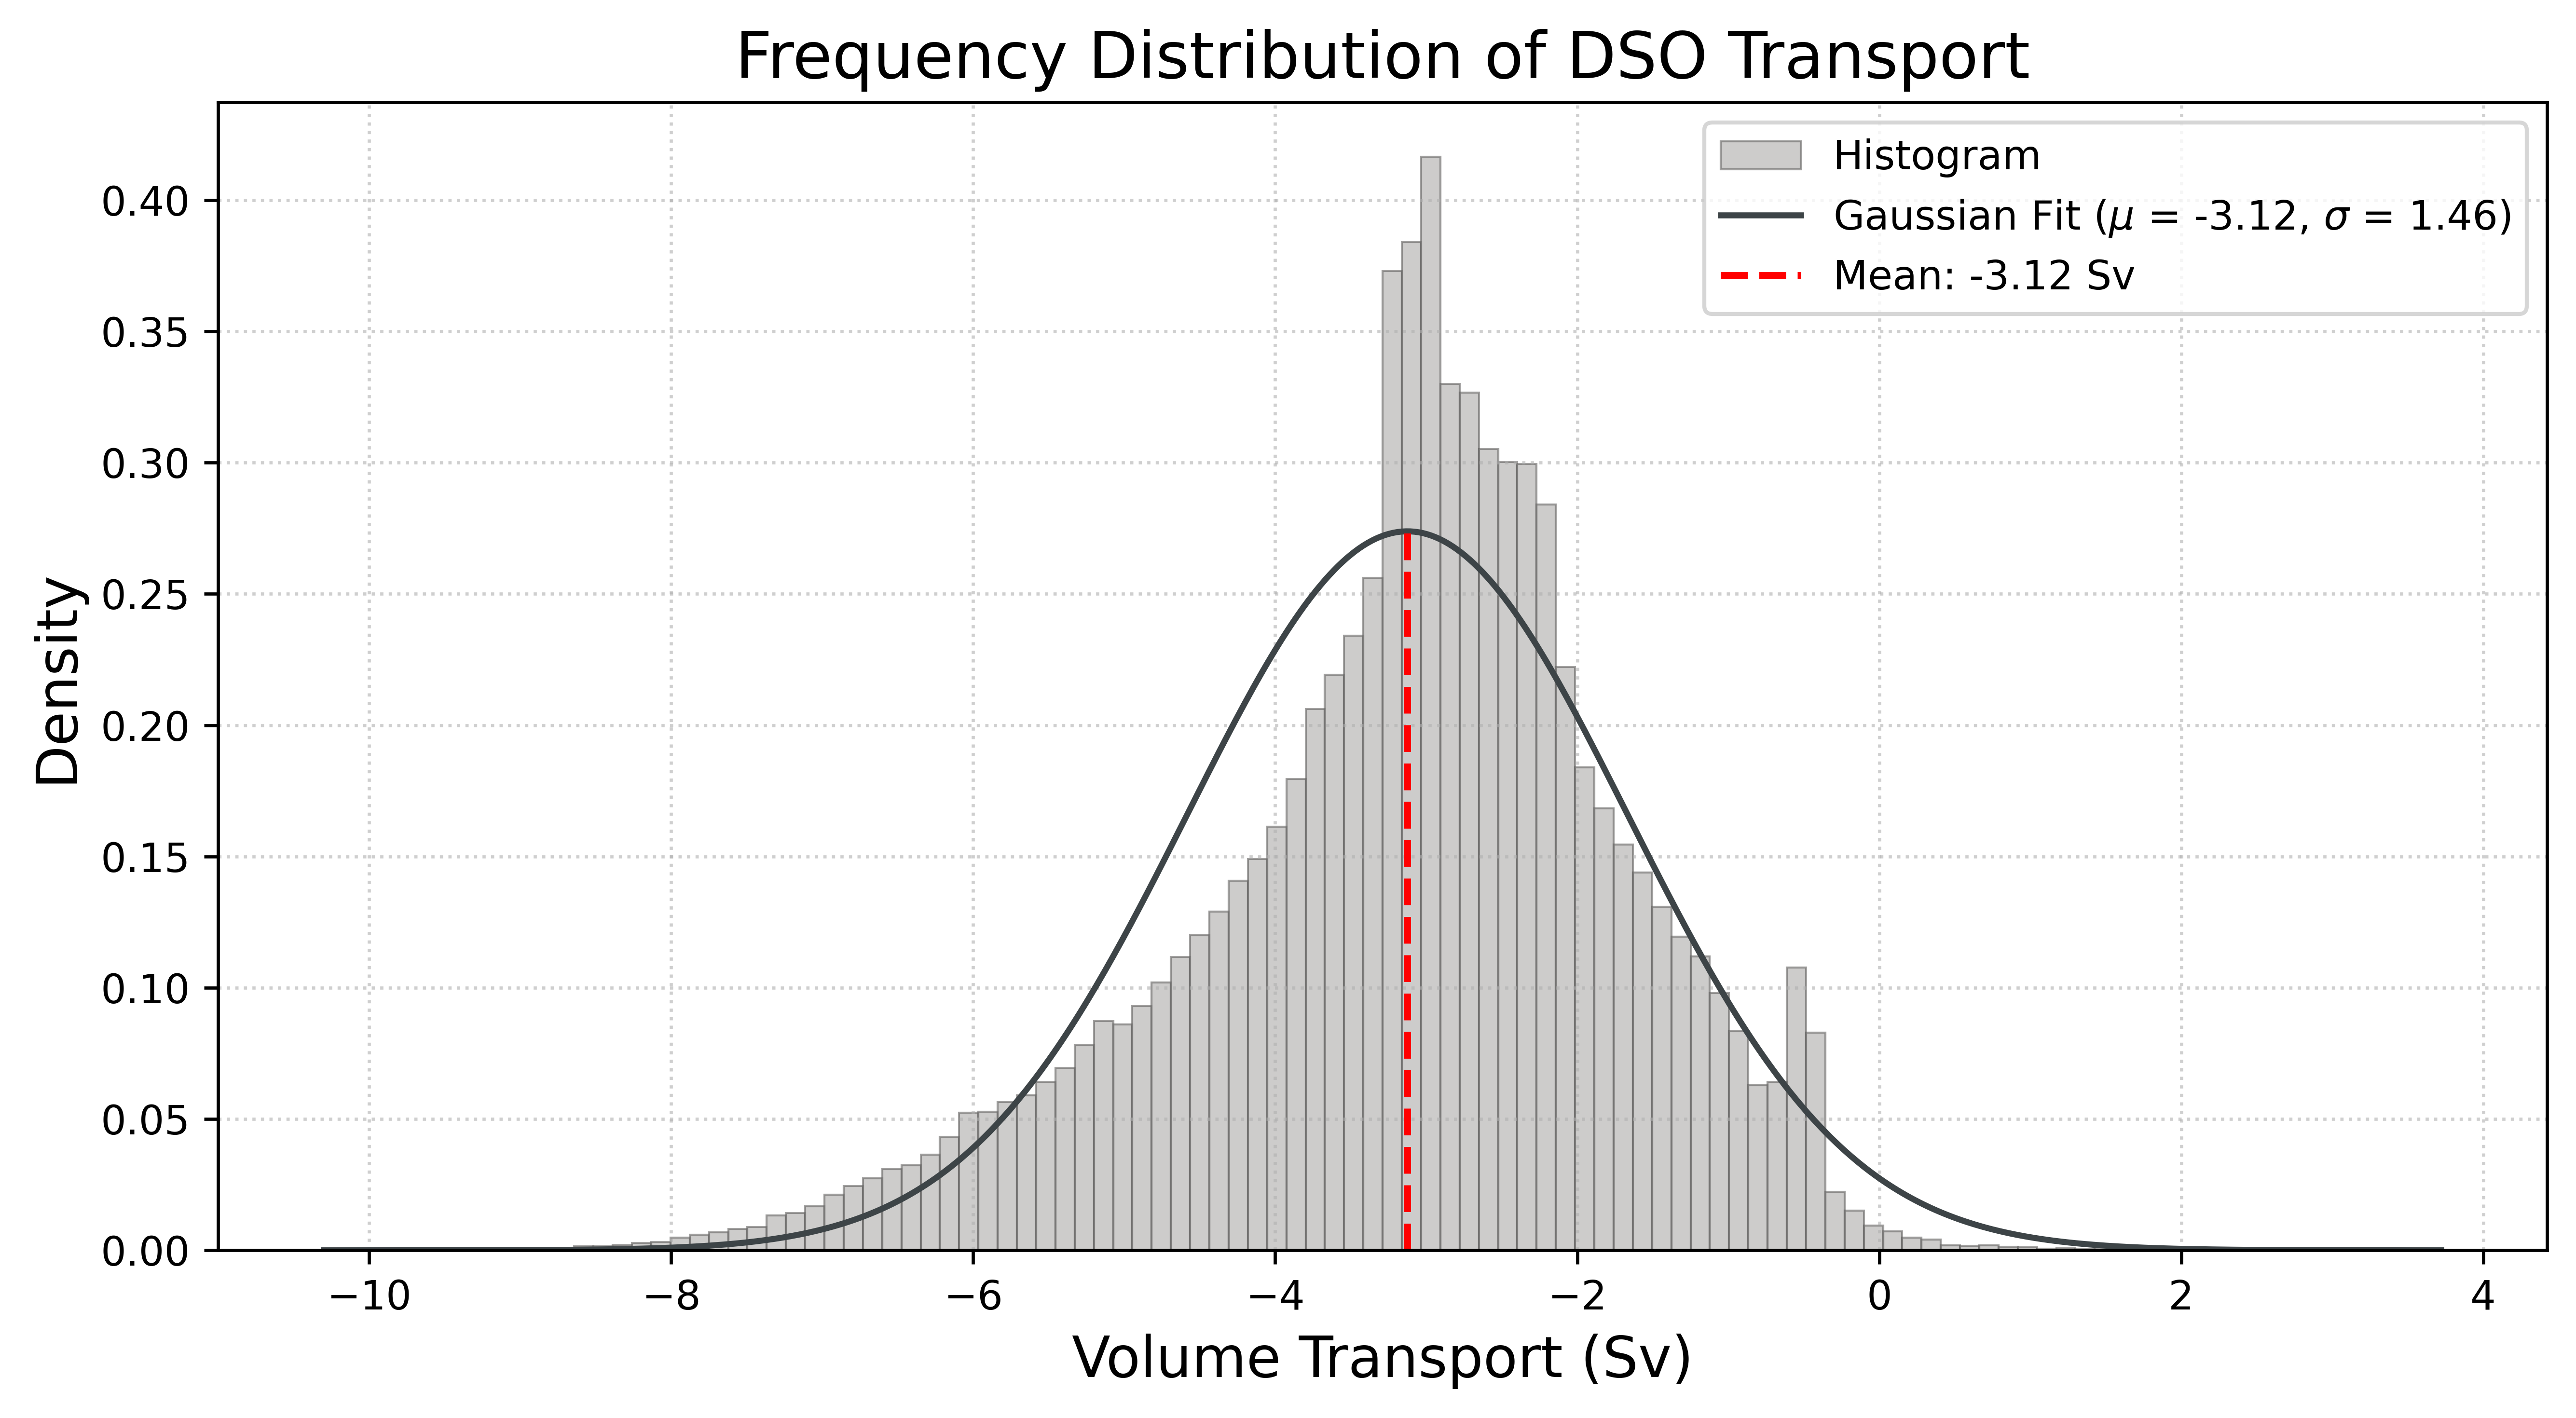

In [86]:
# compute
stats = compute_transport_stats(series_clean, var_name = "DSO")

# plot
fig_distr, ax = plot_transport_distribution(series_clean, mean_val = stats["mean"], var_name = "DSO", dpi = 600)

fig_distr.savefig("../figures/PartA_frequency_distribution_of_DSO_Transport.png", dpi = 600, bbox_inches = "tight")

## Part B The Spectrum

### 1.& 2. Welch's Power Spectrum

Segmenting——Windowing——Periodogram——Averaging

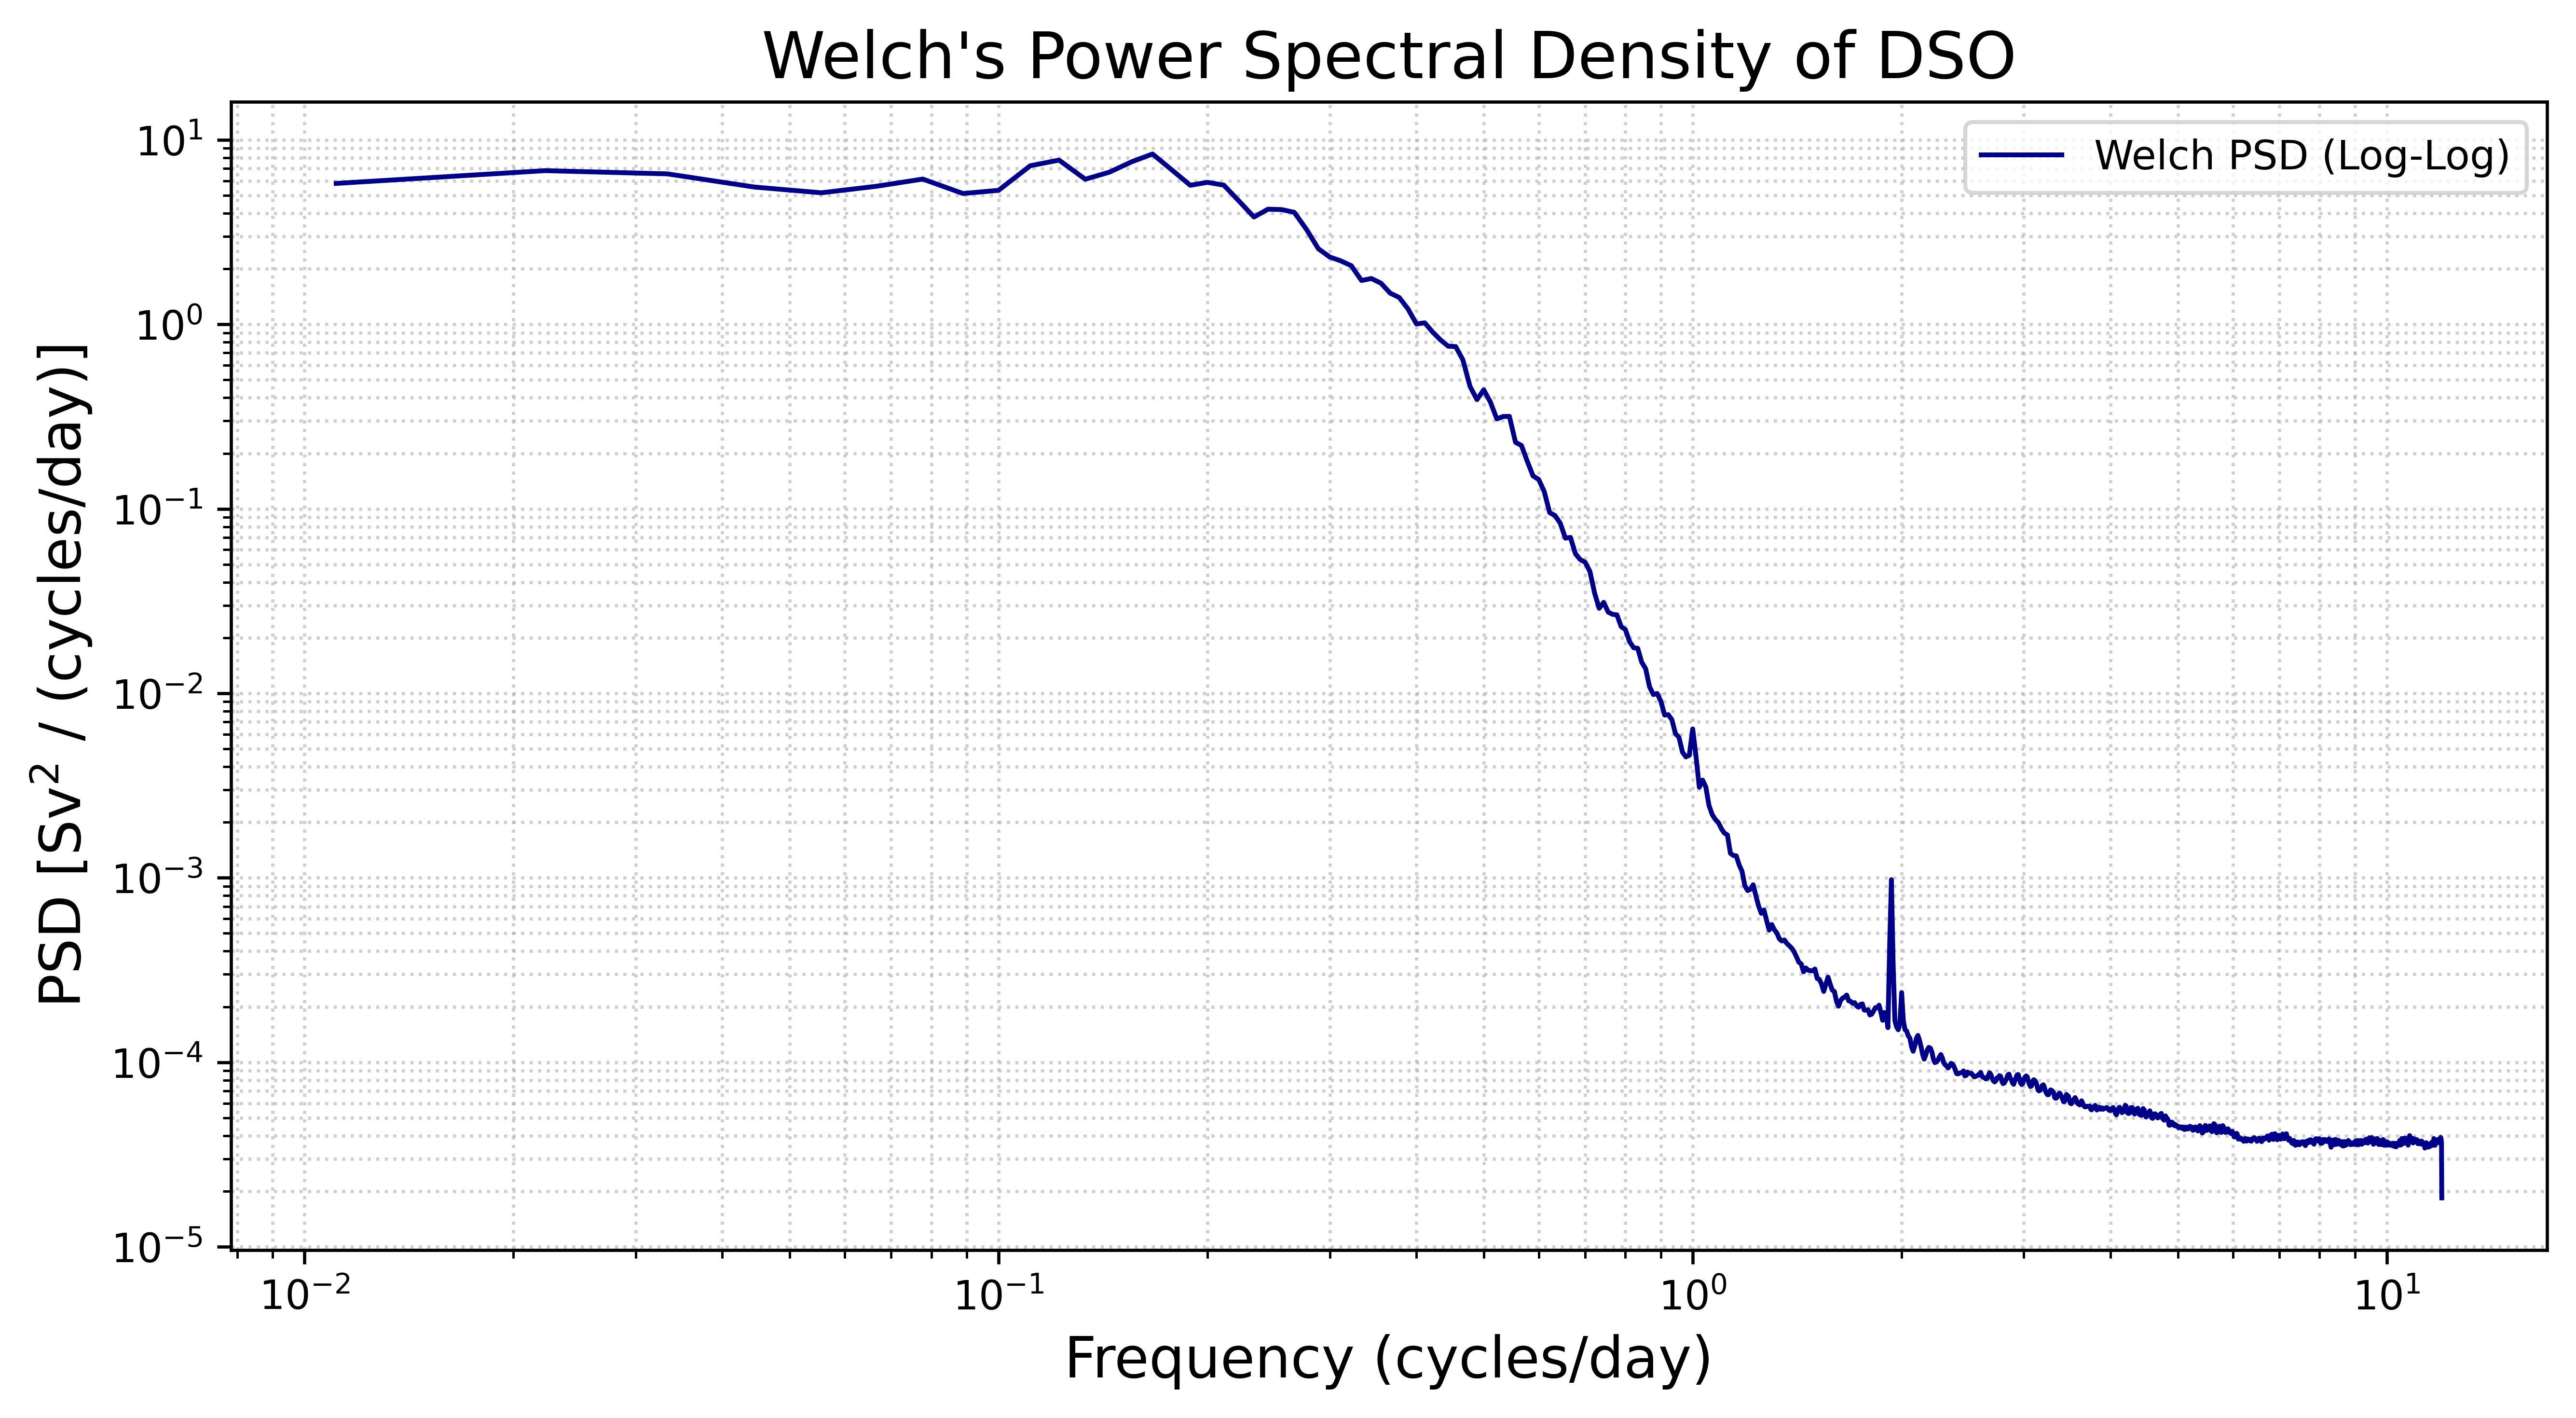

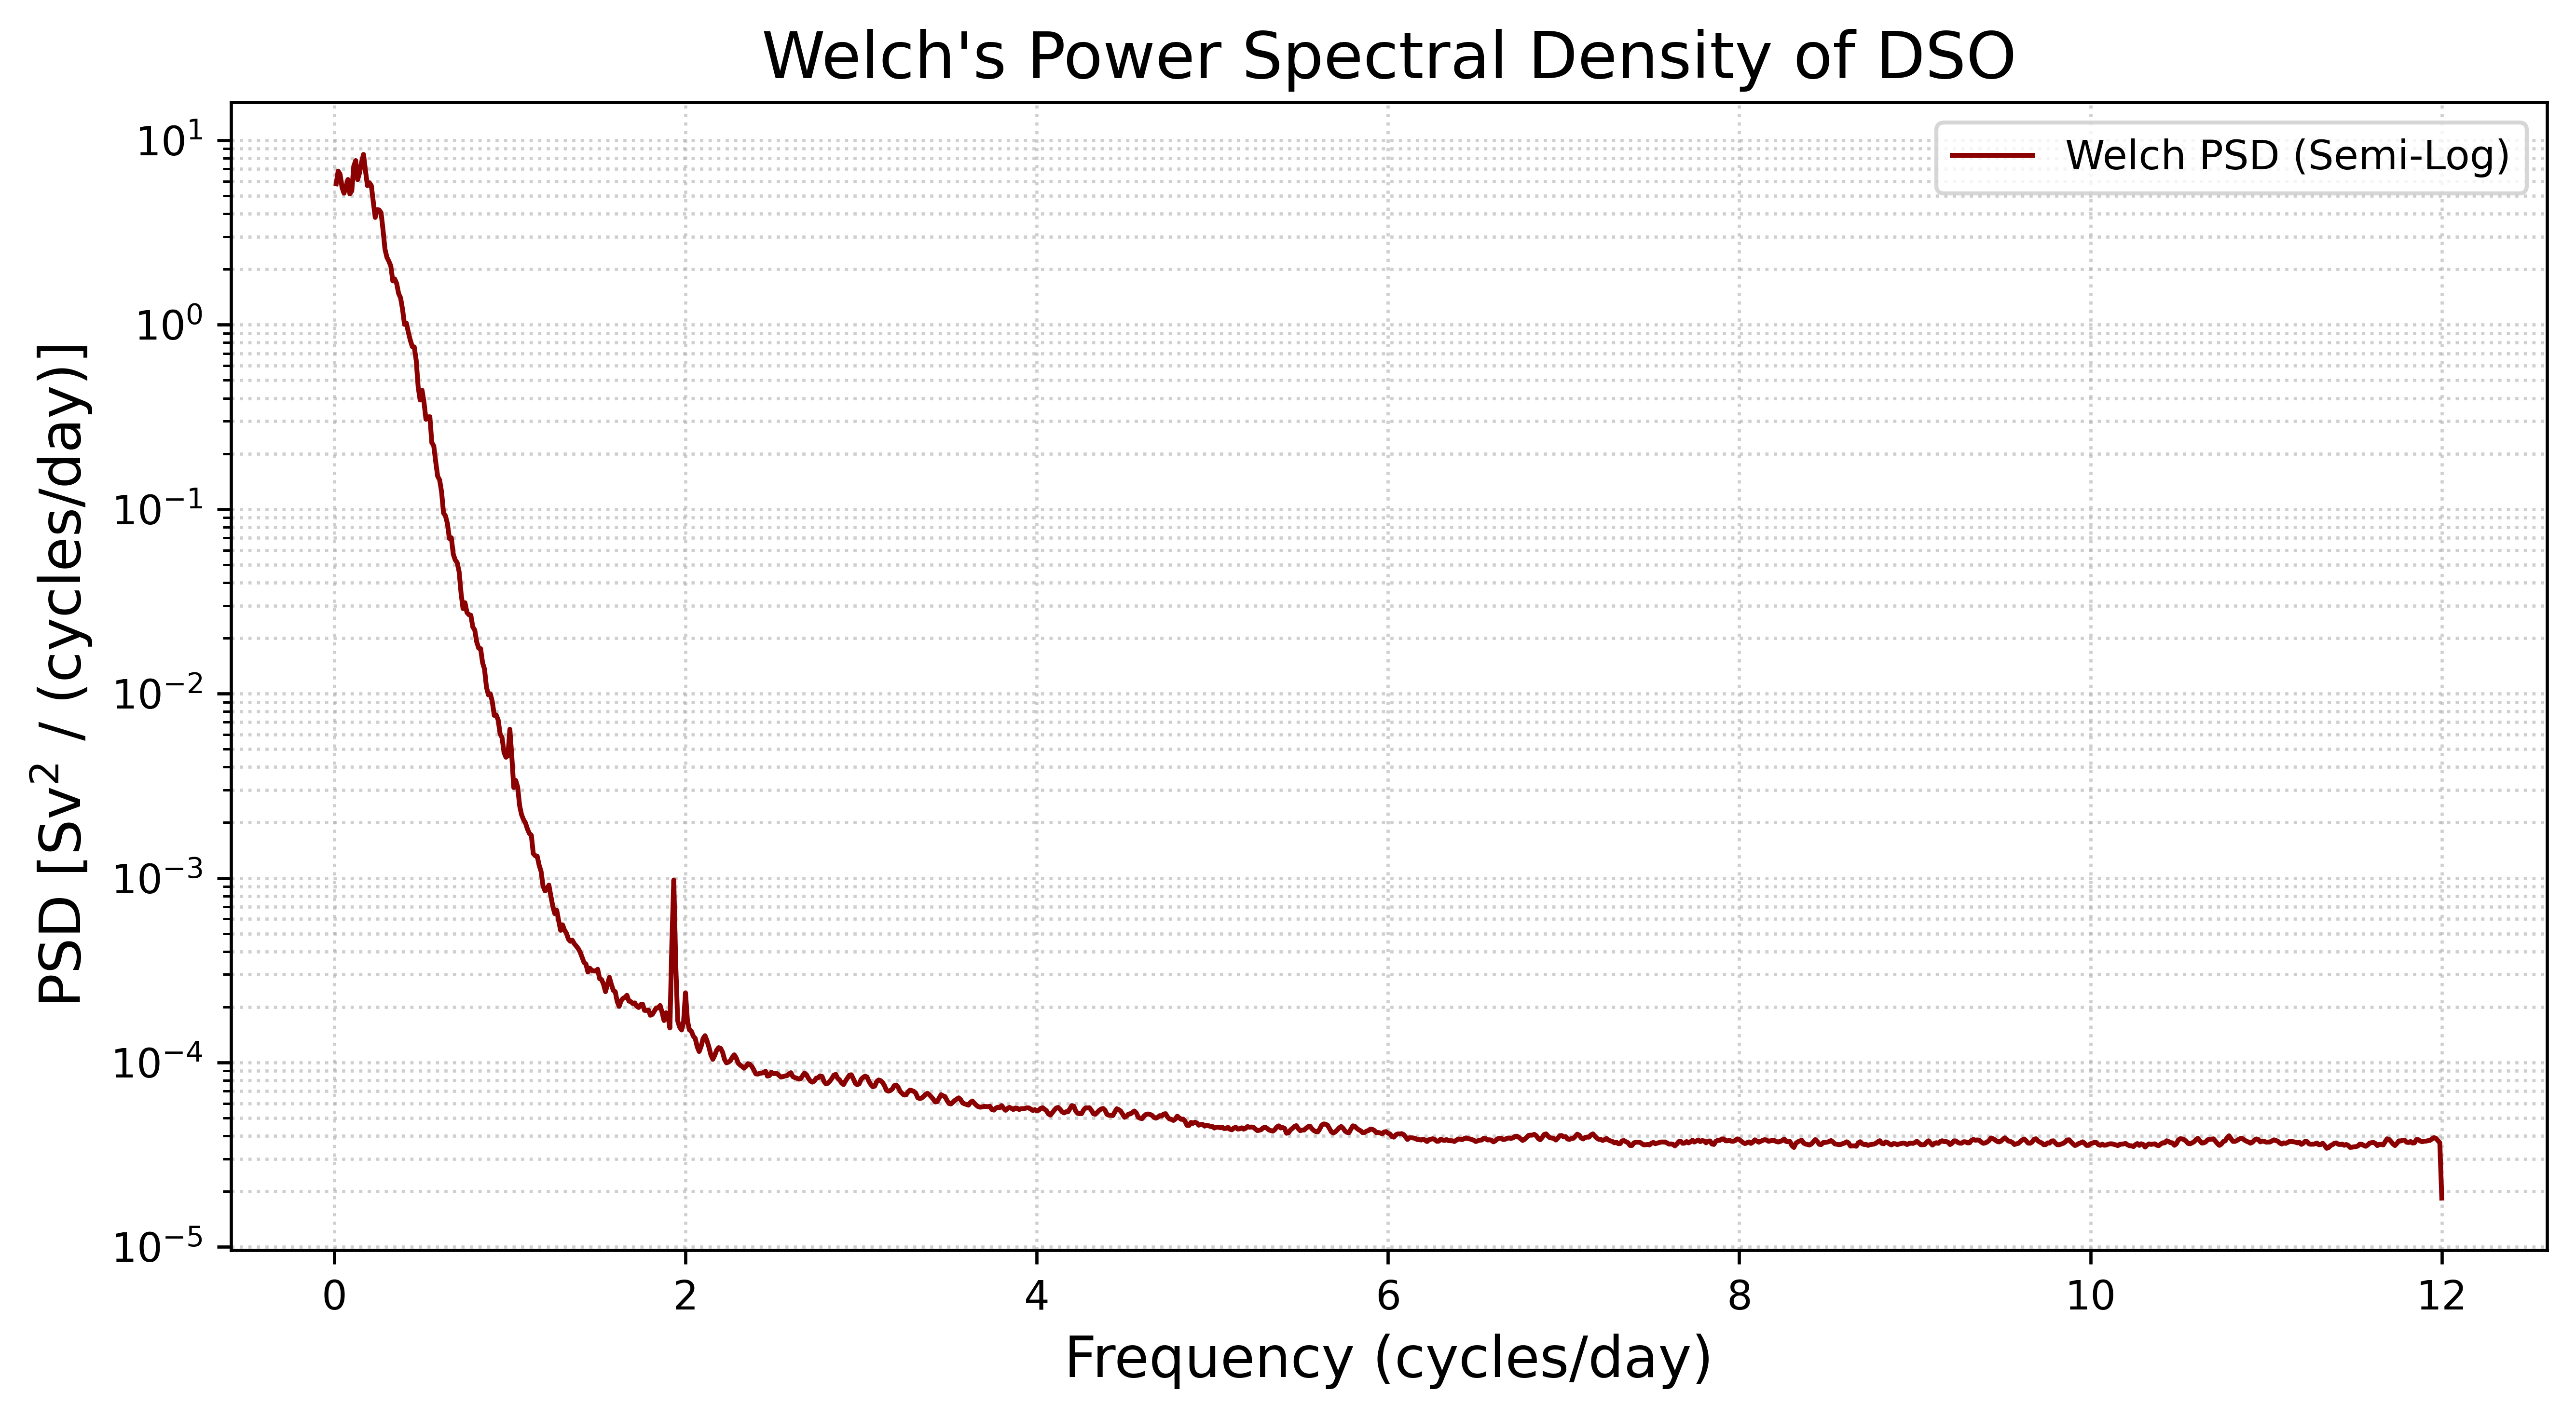

In [77]:
# compute
freqs, psd = calculate_welch_psd(series_clean, fs=24.0) # hourly sampling

# plot log-log 
fig_dl, ax = plot_welch_psd(freqs, psd, var_name = "DSO", scale_type = "log-log", dpi = 600)
fig_dl.savefig("../figures/PartB1_welchs_PSD_log_log.png", dpi = 600, bbox_inches = "tight")

# plot semi-log
fig_sl, ax = plot_welch_psd(freqs, psd, var_name = "DSO", scale_type = "semilog", dpi = 600)
fig_sl.savefig("../figures/PartB1_welchs_PSD_semilog.png", dpi = 600, bbox_inches = "tight")

### 3.  Verify the variance budget with Parseval's Theorem

$$\text{Variance}_{\text{time}} \approx \sum \text{PSD} \times \Delta f$$

In [78]:
results = verify_with_parseval(series_clean, freqs, psd, tolerance=0.10)

Time-domain Variance is 2.122388 Sv²
Frequency-domain Integral (PSD) is 1.931553 Sv²
Difference is 0.191
Relative Error is 8.992%
✅ Test Passed: Parseval's theorem verified successfully!


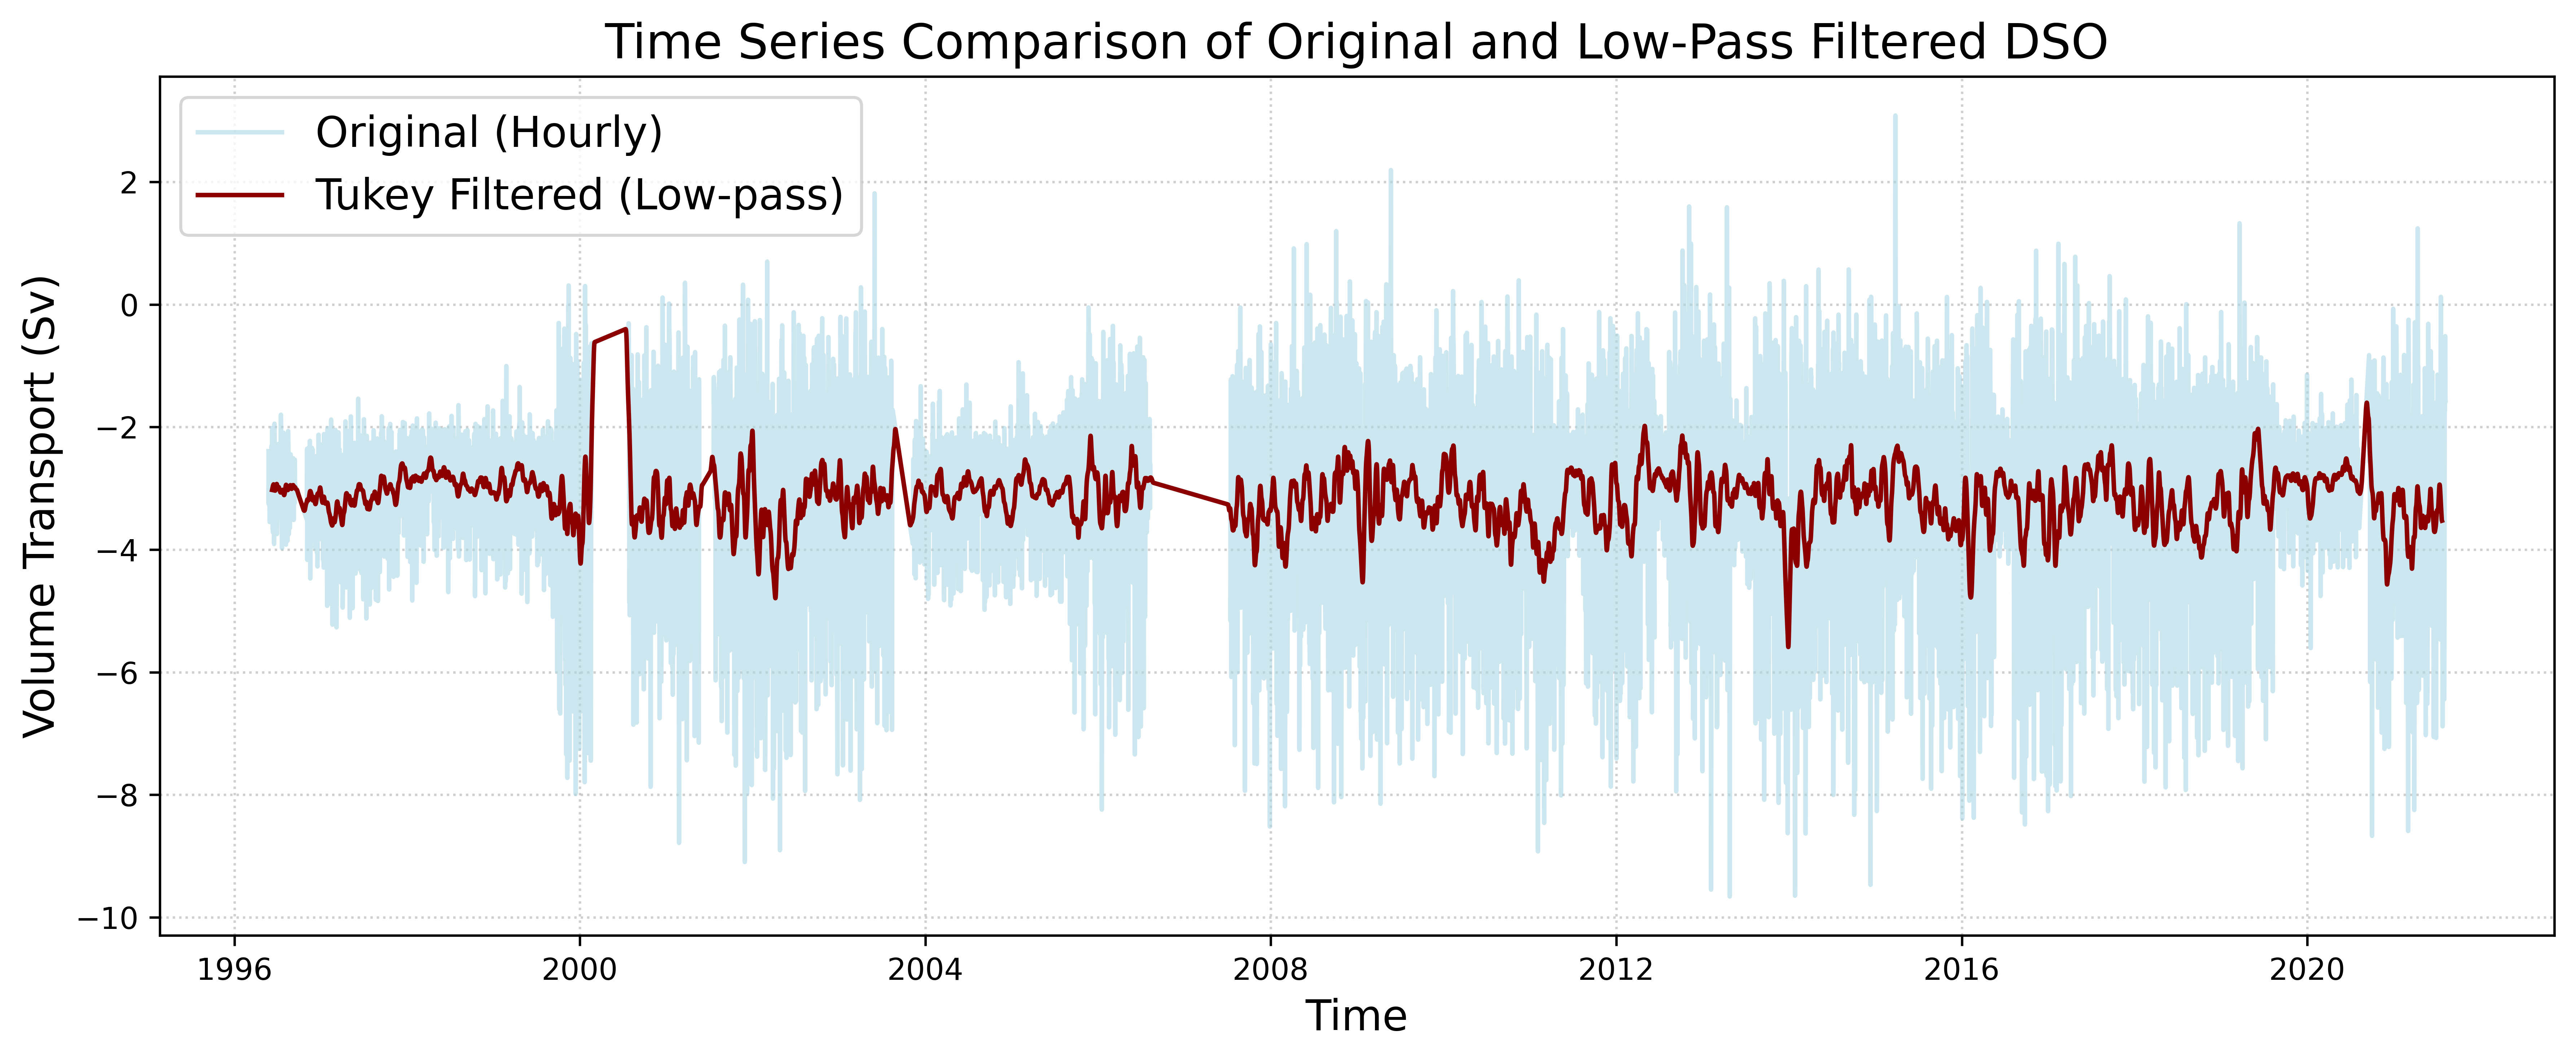

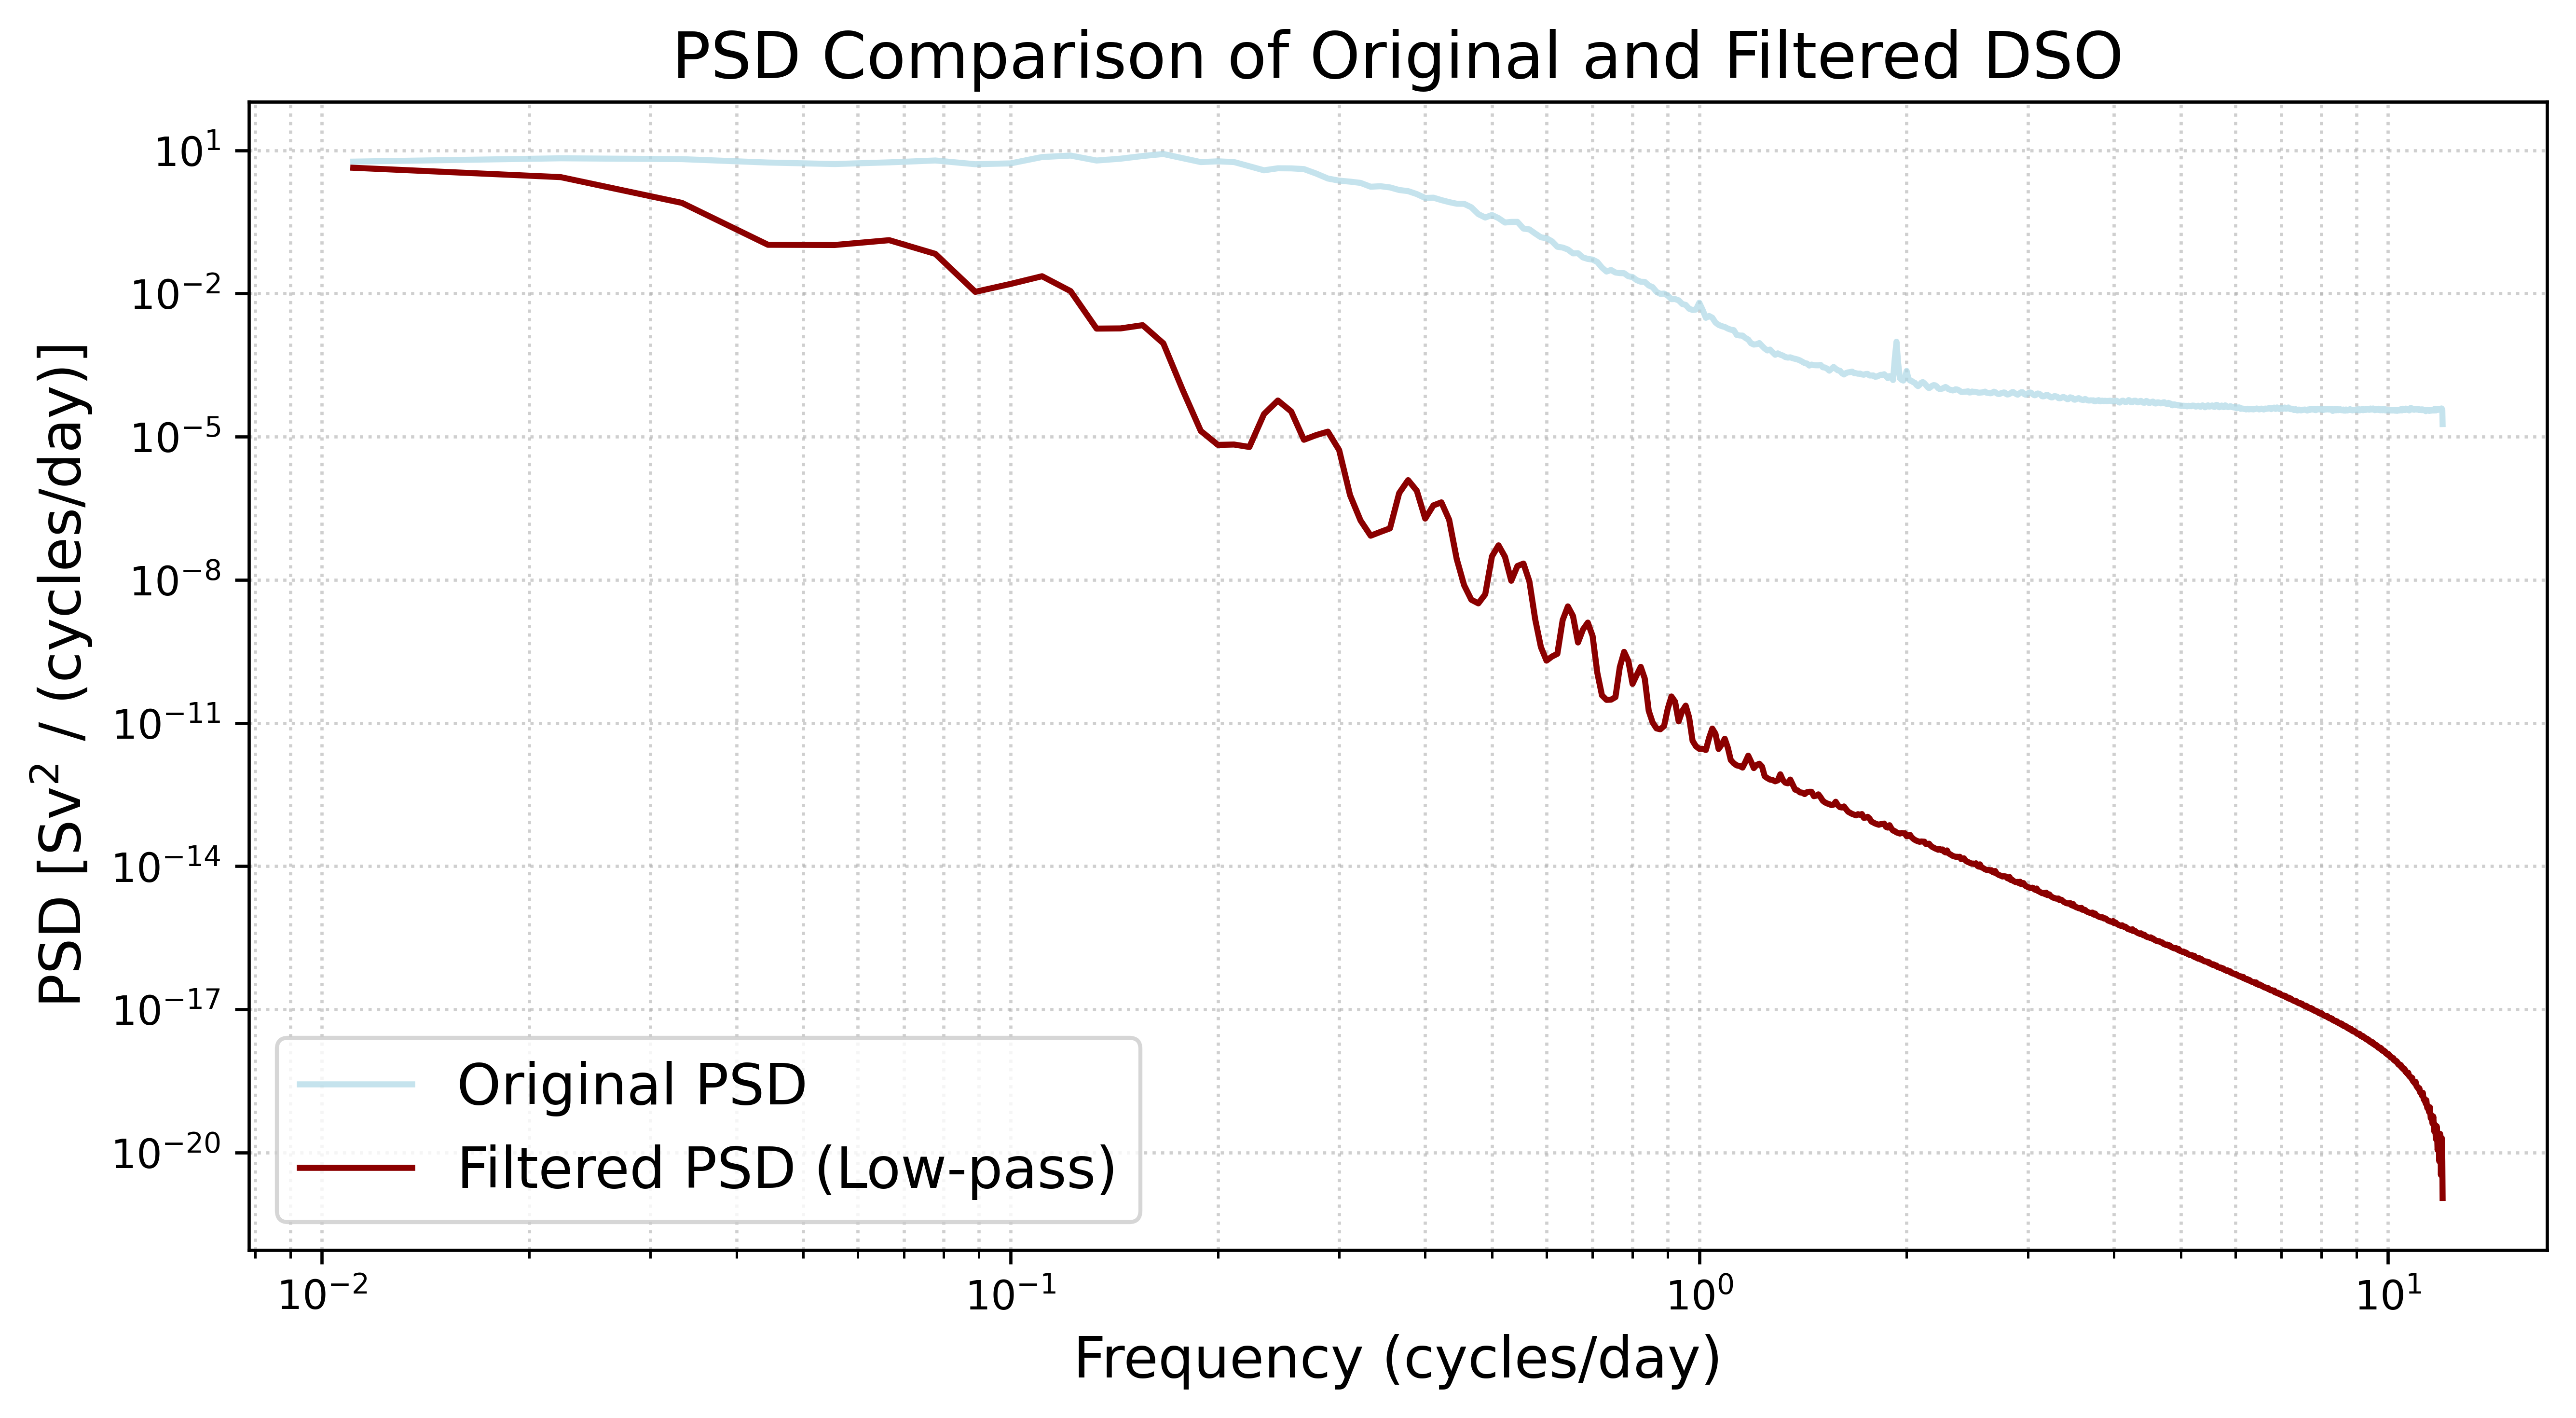

In [79]:
# Apply Turkey low-pass window
window_size = 24 * 30 # 30days
series_filtered = apply_tukey_lowpass_filter(series_clean, window_size = window_size, alpha = 0.5)

# compute Welch's power spectrum
freqs_filt, psd_filt = calculate_welch_psd(series_filtered, fs = 24.0)

# Timeseries comparison
fig_comp, ax = plot_filtered_comparison(series_clean, series_filtered, var_name = "DSO", dpi = 600)
fig_comp.savefig("../figures/PartB3_comparison_of_original_and_lowpass_filtered_DSO.png", dpi = 600, bbox_inches = "tight")

# PSD comparison
fig_PSDcomp, ax = plot_psd_comparison(freqs, psd, freqs_filt, psd_filt, var_name = "DSO", dpi = 600)
fig_PSDcomp.savefig("../figures/PartB3_PSD_comparison_of_original_and_lowpass_filtered_DSO.png", dpi = 600, bbox_inches = "tight")

## Part C Filter Design and Spectral Confidence Interval


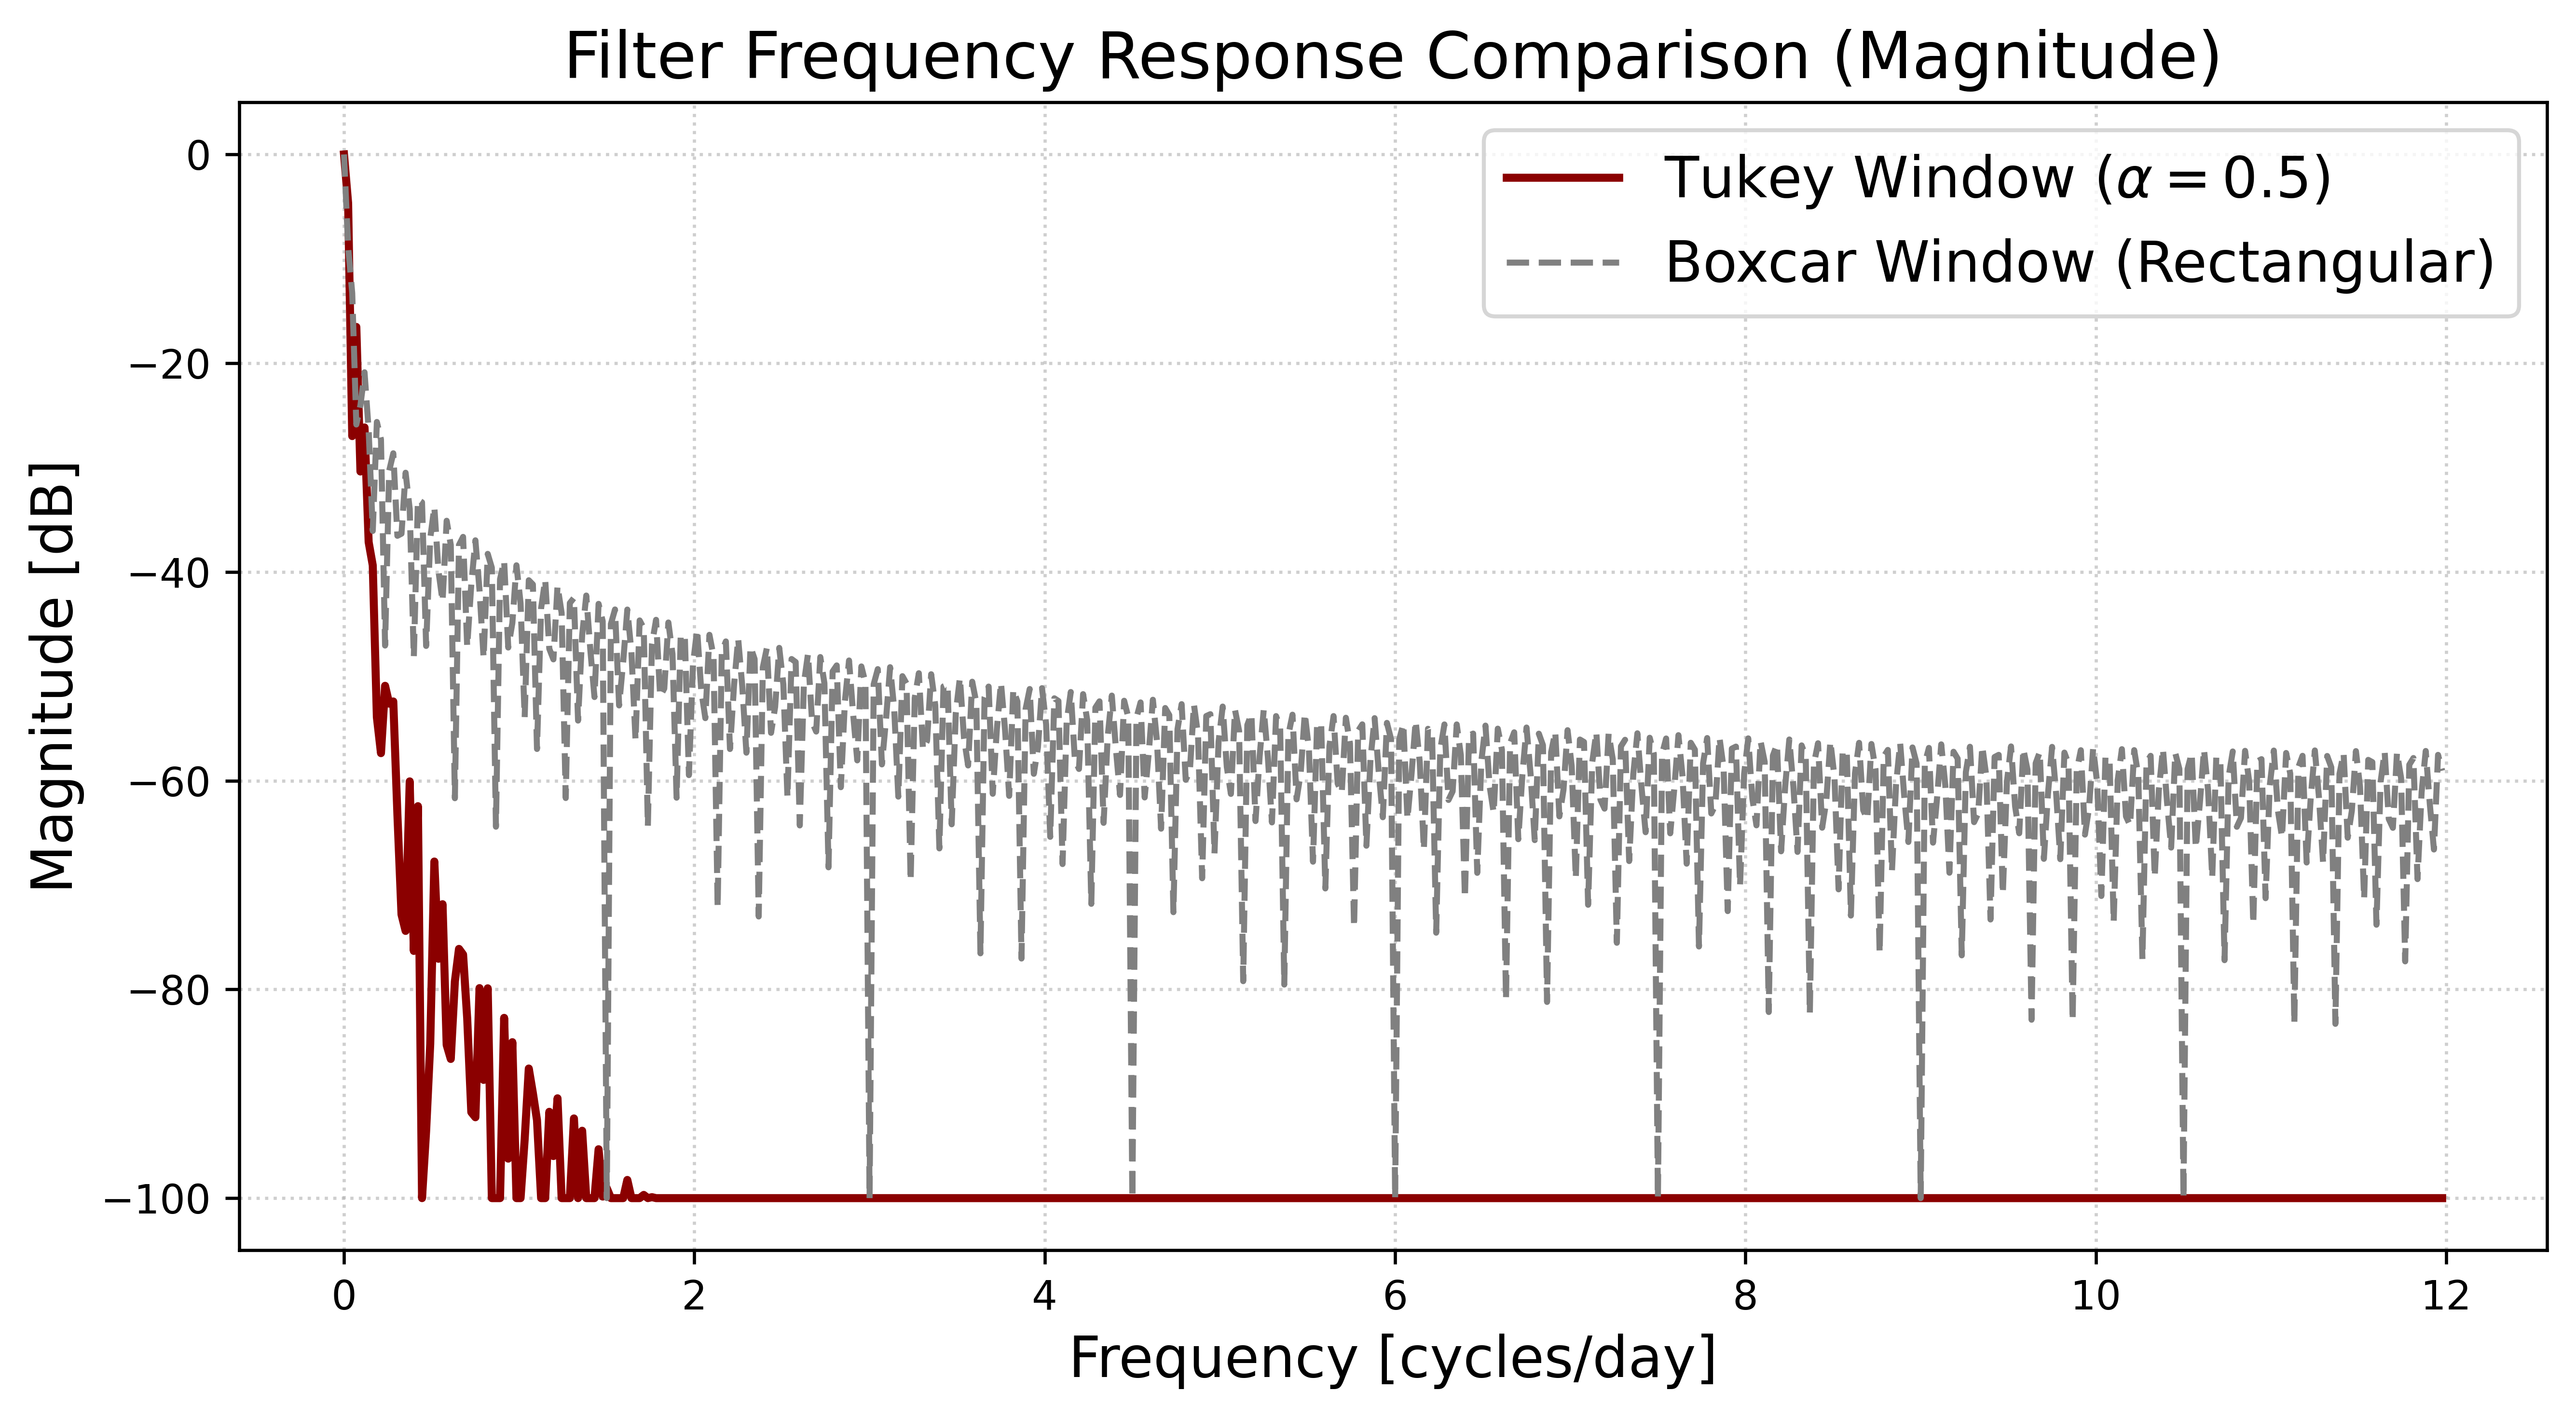

In [80]:
# Generate window coefficients for Tukey and Boxcar (rectangular)
window_size = 24 * 30
window_tukey = signal.windows.tukey(window_size, alpha=0.5)
window_boxcar = signal.windows.boxcar(window_size)

# Normalize weights so the DC gain is exactly 1 (0 dB)
window_tukey /= window_tukey.sum()
window_boxcar /= window_boxcar.sum()

# Compute frequency responses using scipy.signal.freqz
w_tuk, h_tuk = signal.freqz(window_tukey, worN=512)
_, h_box = signal.freqz(window_boxcar, worN=512)

# Convert digital frequency to physical frequency (cycles/day, fs = 24.0)
freqs_resp = (w_tuk / np.pi) * (24.0 / 2.0)

# Convert magnitudes to decibels (dB)
tukey_db = 20 * np.log10(np.maximum(np.abs(h_tuk), 1e-5))
boxcar_db = 20 * np.log10(np.maximum(np.abs(h_box), 1e-5))

# Plot and compare the frequency responses
fig_Freqcomp, ax = plot_filter_frequency_responses(freqs_resp, tukey_db, boxcar_db, dpi = 600)
fig_Freqcomp.savefig("../figures/PartC_PSD_comparison_of_original_and_lowpass_filtered_DSO.png", dpi = 600, bbox_inches = "tight")


Chi-Squared Confidence Interval

Calculated Equivalent Degrees of Freedom (EDF): 181.86


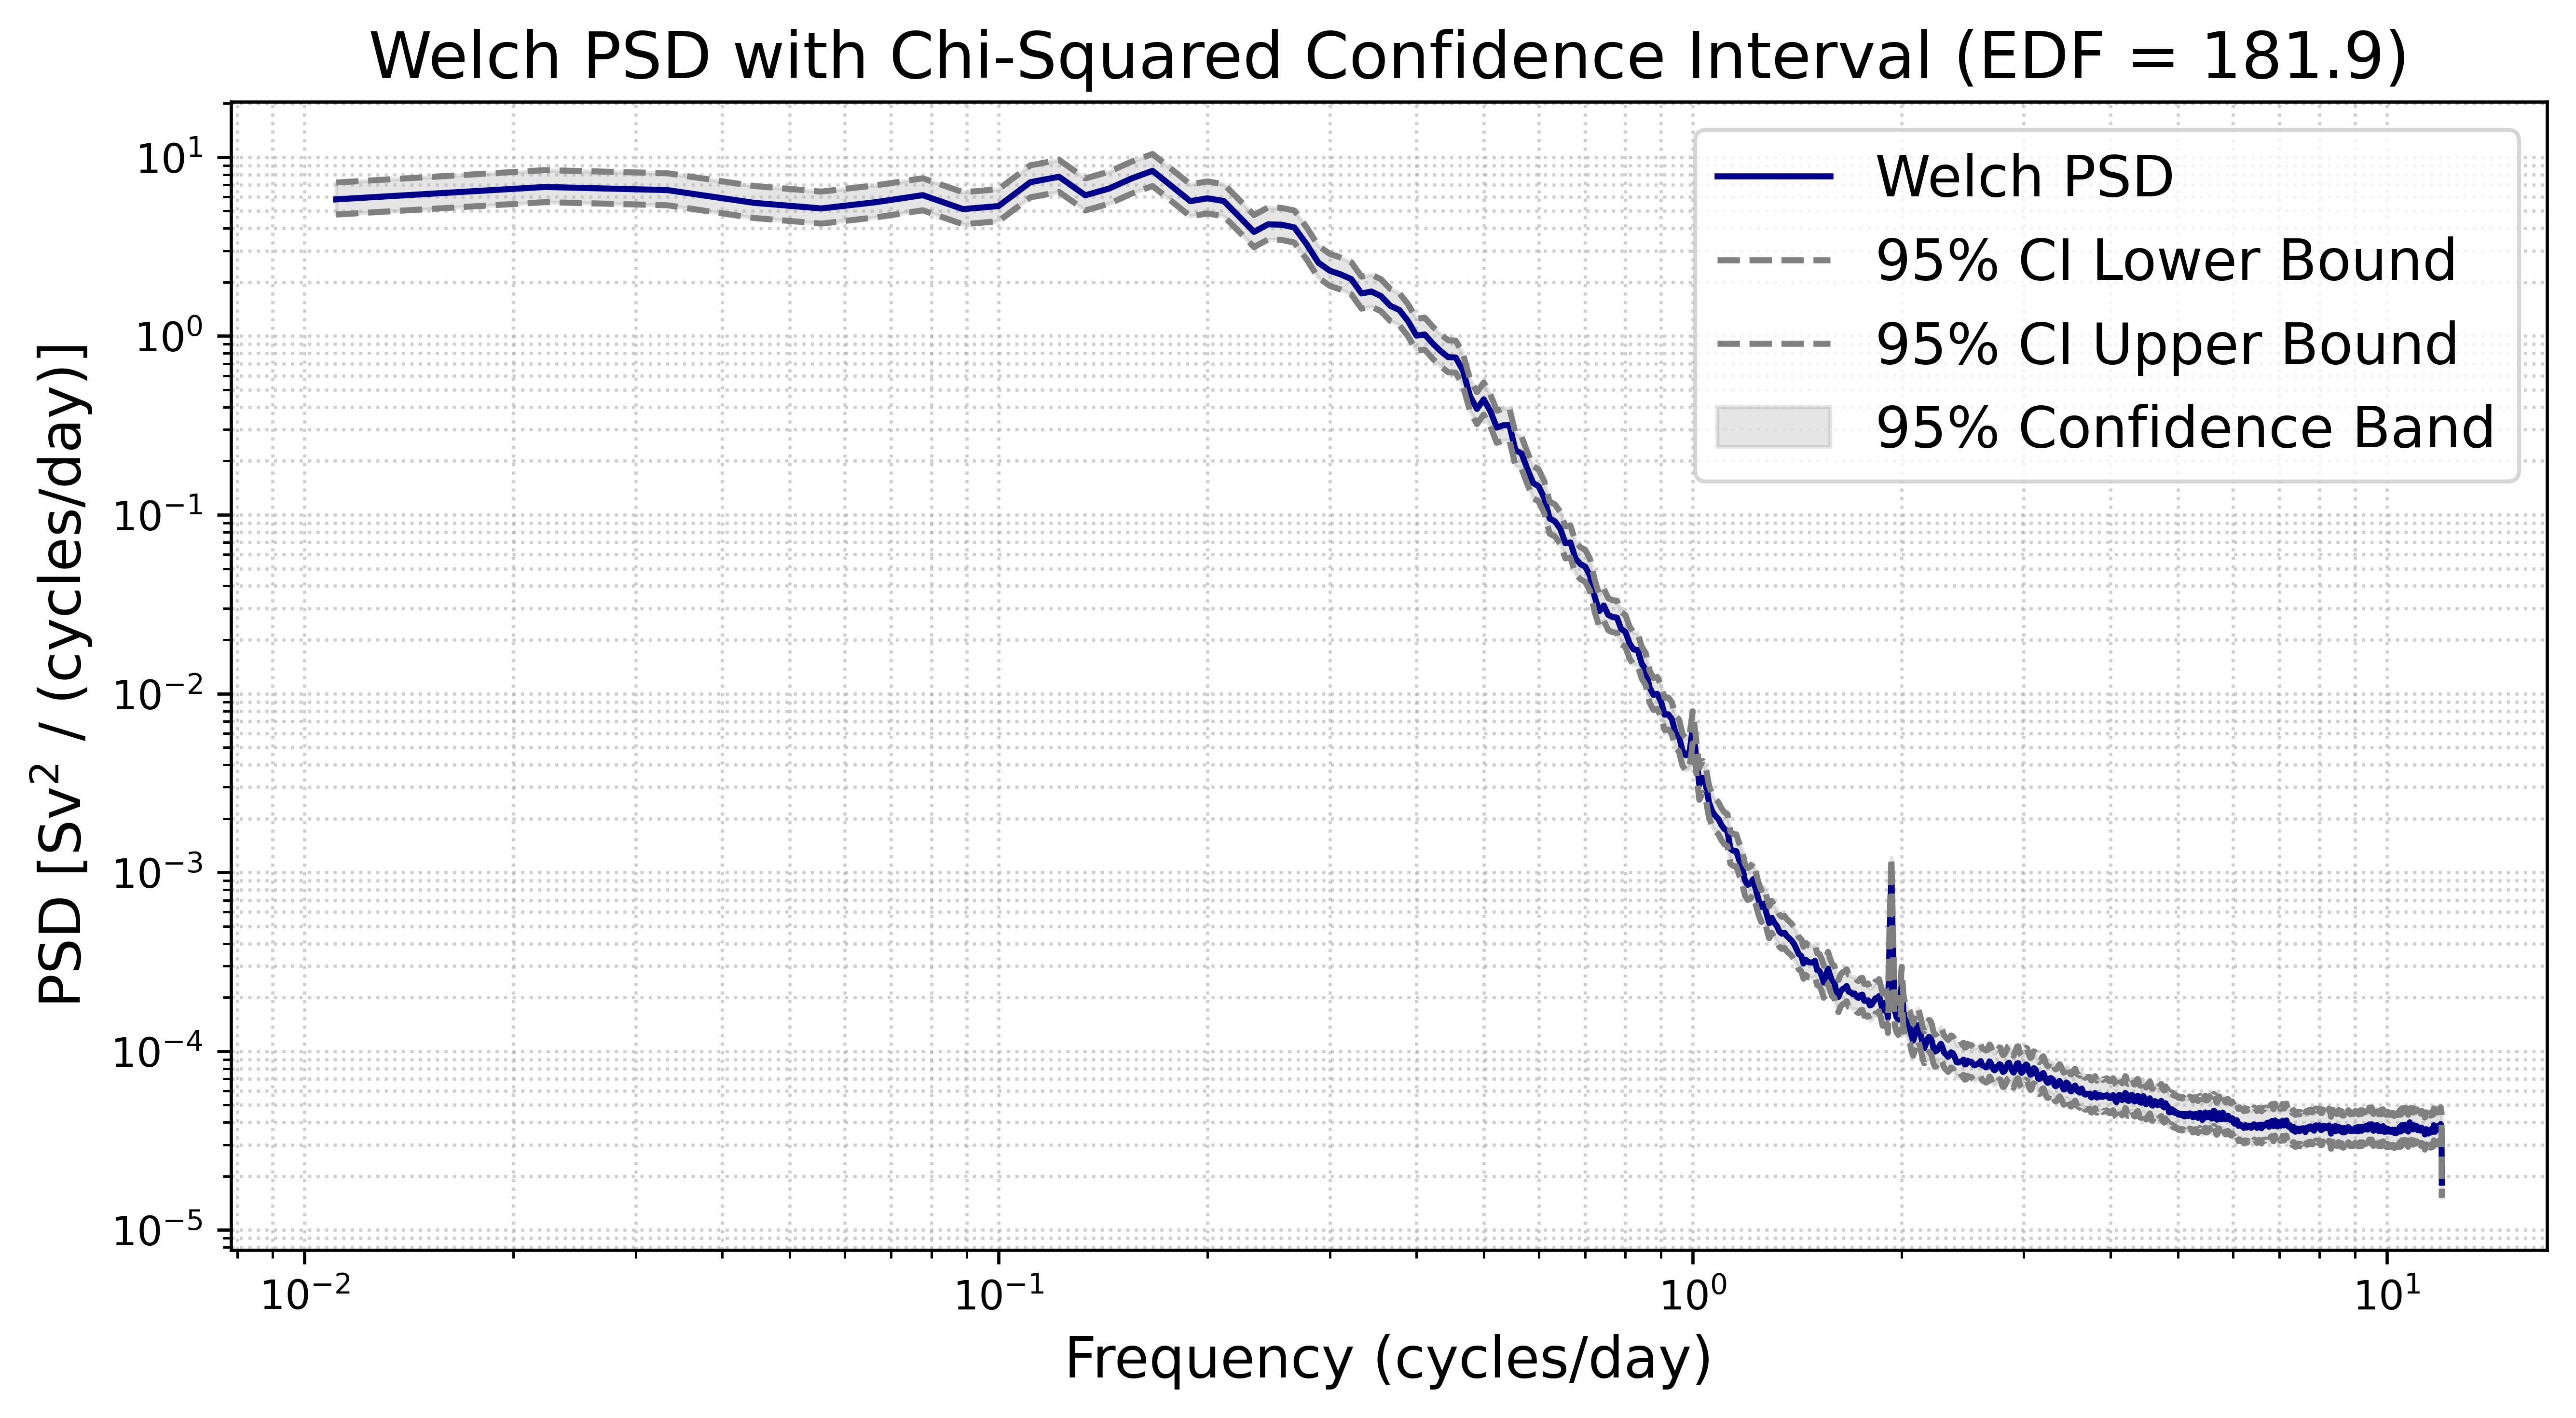

In [81]:
# 1. Compute Chi-squared confidence intervals and Equivalent Degrees of Freedom (EDF)
n_total_points = len(series_clean)
lower_ci, upper_ci, dof_val = compute_confidence_interval(
    psd, 
    nperseg=24*90, 
    n_total=n_total_points, 
    alpha=0.05
)

print(f"Calculated Equivalent Degrees of Freedom (EDF): {dof_val:.2f}")

# 2. Plot Welch PSD with 95% confidence bands
fig_chisq, ax = plot_psd_with_confidence_interval(freqs, psd, lower_ci, upper_ci, dof_val, dpi = 600)
fig_chisq.savefig("../figures/PartC_welch_PSD_with_ChiSqured_Confidence_Interval.png", dpi = 600, bbox_inches = "tight")
